In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

import seaborn as sns 

from scipy import stats 

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score 

In [2]:
# Load dataset
df = pd.read_csv("./titanic/train.csv")

In [3]:
# Data preprocessing
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [4]:
# Converting text to numbers
df["Sex"] = df["Sex"].replace({"male": 0, "female": 1}).astype(int) 
df["Embarked"] = df["Embarked"].replace({"C": 0, "Q": 1, "S": 2}).astype(int)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,2


In [5]:
# Feature selection
df = df[["Survived", "Pclass", "Sex", "Age", "Fare", "Embarked"]]
x = df.drop("Survived", axis=1).values 
y = df["Survived"].values
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,0,22.0,7.2500,2
1,1,1,1,38.0,71.2833,0
2,1,3,1,26.0,7.9250,2
3,1,1,1,35.0,53.1000,2
4,0,3,0,35.0,8.0500,2


In [6]:
# KNN implementation
class KNN:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None
            
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y 
    
    def predict(self, X):
        predictions = []
        for p in X:
            # vse provadime vektorove (zrychleni)
            # vypocet vzdalenosti
            euclidean_distances = [self._euclidean_distance(p, q) for q in self.X_train]
            
            # seradime dle vzdalenosti a vybereme k nejlepsich
            sorted_k = np.argsort(euclidean_distances)[:self.k]
            
            # zjistime predikce nejblizsich sousedu
            k_nearest = [self.y_train[y] for y in sorted_k]
            
            # vybereme nejcastejsi predikci 
            predictions.append(stats.mode(k_nearest, keepdims=True).mode[0])        
        return np.array(predictions)
    
    def _euclidean_distance(self, p, q):
        return np.sqrt(np.sum((p - q) ** 2))



In [7]:
# Train/test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=50)

In [8]:
# Normalization
scaler = StandardScaler() 
x_train = scaler.fit_transform(x_train) 
x_test = scaler.transform(x_test)

In [9]:
# Small k
model_k_small = KNN(k=3) 
model_k_small.fit(x_train, y_train) 
pred_small = model_k_small.predict(x_test) 
acc_small = accuracy_score(y_test, pred_small)

print(f"k = 3 → Accuracy: {acc_small:.4f}")

k = 3 → Accuracy: 0.7821


In [10]:
# Larger k
model_k_larger = KNN(k=9) 
model_k_larger.fit(x_train, y_train) 
pred_lager = model_k_larger.predict(x_test) 
acc_larger = accuracy_score(y_test, pred_lager)

print(f"k = 9 → Accuracy: {acc_larger:.4f}")

k = 9 → Accuracy: 0.7877


In [11]:
# Experiment: k values
k_values = range(1, 21) 
accuracies = [] 

for k in k_values: 
    model = KNN(k=k) 
    model.fit(x_train, y_train) 
    y_pred = model.predict(x_test) 
    accuracies.append(accuracy_score(y_test, y_pred))

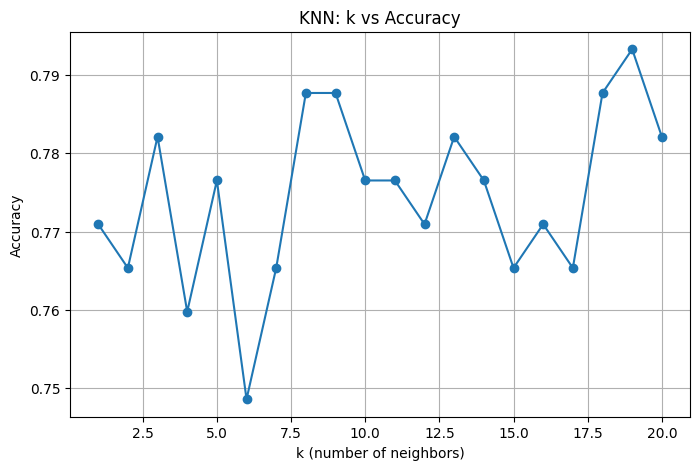

In [12]:
# Results
plt.figure(figsize=(8, 5)) 
plt.plot(k_values, accuracies, marker='o') 
plt.xlabel("k (number of neighbors)") 
plt.ylabel("Accuracy") 
plt.title("KNN: k vs Accuracy")
plt.grid() 
plt.show()

In [13]:
# Select best k
best_k = k_values[np.argmax(accuracies)] 
print(f"Best k: {best_k}")

Best k: 19


In [14]:
# Final model
model = KNN(k=best_k) 
model.fit(x_train, y_train) 
y_pred = model.predict(x_test)

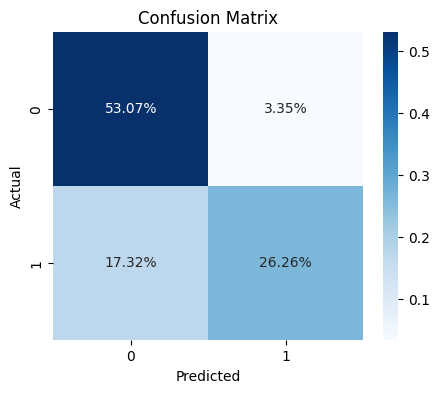

              precision    recall  f1-score   support

           0       0.75      0.94      0.84       101
           1       0.89      0.60      0.72        78

    accuracy                           0.79       179
   macro avg       0.82      0.77      0.78       179
weighted avg       0.81      0.79      0.78       179



In [15]:
# Evaluation
cf_matrix = confusion_matrix(y_test, y_pred) 

plt.figure(figsize=(5,4)) 
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, fmt=".2%", cmap="Blues") 
plt.title("Confusion Matrix") 
plt.xlabel("Predicted") 
plt.ylabel("Actual") 
plt.show() 
print(classification_report(y_test, y_pred))